<a href="https://colab.research.google.com/github/v-n-n/DS_Course0_Week1_Module2_DataTypes/blob/main/Copy_of_financial_loan_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


FinTech Innovations currently relies heavily on manual loan review. This process can be slow and may lead to inconsistent decisions between loan officers. A machine-learning model could provide a standardized risk estimate to support faster and more consistent assessment.

STAKEHOLDERS

Loan officers need a consistent risk estimate that supports their decisions.

Applicants need timely and fair assessments.

Risk analysts need reliable model performance and monitoring.

FinTech Innovations and partner banks need to reduce losses while meeting regulatory expectations.

Compliance and governance teams need explanations and evidence that the model is not being used irresponsibly.

I selected regression because RiskScore is a continuous numerical target. Predicting a continuous score gives loan officers a measure of risk that can support judgment rather than forcing the model to make a direct approval decision. This approach is appropriate for the stated option of generating risk scores for loan officers.

I used MAE, RMSE, and R² to evaluate the regression models. MAE answers the question: “On average, how many risk-score points away are the predictions?” RMSE gives greater weight to large errors, which is useful because some applicants may receive substantially inaccurate risk estimates. R² measures how much variation in the risk score is explained by the model compared with a mean-prediction baseline.

In [ ]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv("financial_loan_data.csv")

In [ ]:
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [ ]:
df.shape

(20000, 35)

In [ ]:
df.columns.to_list()

['Age',
 'AnnualIncome',
 'CreditScore',
 'EmploymentStatus',
 'EducationLevel',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'MaritalStatus',
 'NumberOfDependents',
 'HomeOwnershipStatus',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'LoanApproved',
 'RiskScore']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

,0
MaritalStatus,1331
EducationLevel,901
SavingsAccountBalance,572


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
display(df["RiskScore"].describe())

,RiskScore
count,20000.000000
mean,50.766780
std,7.778262
min,28.800000
25%,46.000000
50%,52.000000
75%,56.000000
max,84.000000


In [ ]:
display(df["LoanApproved"].value_counts(dropna=False))

,count
LoanApproved,
0,15220
1,4780


In [ ]:
# Displaying object-column examples and unique values
object_columns = df.select_dtypes(include="object").columns

print("Object columns:")
print(object_columns.tolist())

for column in object_columns:
    print(f"\n{column}")
    print("Number of unique values:", df[column].nunique(dropna=False))
    print(df[column].value_counts(dropna=False).head(15))

Object columns:
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

AnnualIncome
Number of unique values: 17516
AnnualIncome
$15,000.00     584
$300,000.00     26
$26,721.00       4
$68,064.00       4
$34,958.00       4
$24,627.00       4
$26,437.00       4
$36,604.00       4
$38,144.00       3
$95,552.00       3
$47,153.00       3
$43,720.00       3
$29,952.00       3
$45,080.00       3
$32,641.00       3
Name: count, dtype: int64

EmploymentStatus
Number of unique values: 3
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
Number of unique values: 6
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

MaritalStatus
Number of unique values: 5
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331

In [ ]:
# Inspecting AnnualIncome formatting
print("\nAnnualIncome examples:")
display(df["AnnualIncome"].head(20))

print("\nAnnualIncome missing values:", df["AnnualIncome"].isna().sum())
print("AnnualIncome unique values:", df["AnnualIncome"].nunique(dropna=False))


AnnualIncome examples:


,AnnualIncome
0,"$39,948.00"
1,"$39,709.00"
2,"$40,724.00"
3,"$69,084.00"
4,"$103,264.00"
5,"$178,310.00"
6,"$51,250.00"
7,"$97,345.00"
8,"$116,841.00"
9,"$40,615.00"



AnnualIncome missing values: 0
AnnualIncome unique values: 17516


In [ ]:
# Comparing RiskScore for missing and non-missing values
missingness_summary = []

for column in ["MaritalStatus", "EducationLevel", "SavingsAccountBalance"]:
    missing_group = df.loc[df[column].isna(), "RiskScore"]
    non_missing_group = df.loc[df[column].notna(), "RiskScore"]

    missingness_summary.append({
        "column": column,
        "missing_count": len(missing_group),
        "non_missing_count": len(non_missing_group),
        "missing_mean_risk": missing_group.mean(),
        "non_missing_mean_risk": non_missing_group.mean(),
        "missing_median_risk": missing_group.median(),
        "non_missing_median_risk": non_missing_group.median()
    })

print("\nRiskScore comparison by missingness:")
display(pd.DataFrame(missingness_summary))



RiskScore comparison by missingness:


,column,missing_count,non_missing_count,missing_mean_risk,non_missing_mean_risk,missing_median_risk,non_missing_median_risk
0,MaritalStatus,1331,18669,50.648234,50.775232,52.0,52.0
1,EducationLevel,901,19099,54.083241,50.610325,53.0,52.0
2,SavingsAccountBalance,572,19428,50.297203,50.780605,51.1,52.0


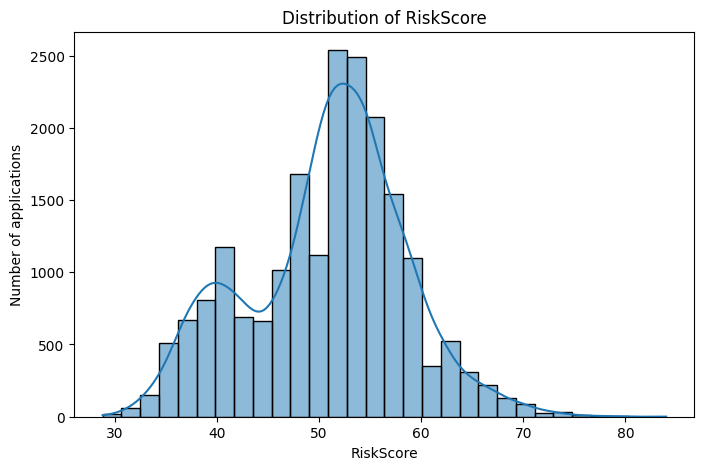

In [ ]:
# RiskScore distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="RiskScore", bins=30, kde=True)
plt.title("Distribution of RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Number of applications")
plt.show()


In [ ]:
# Boxplots for selected numerical variables
selected_numeric = [
    "RiskScore",
    "CreditScore",
    "LoanAmount",
    "AnnualIncome",
    "TotalDebtToIncomeRatio",
    "NetWorth"
]


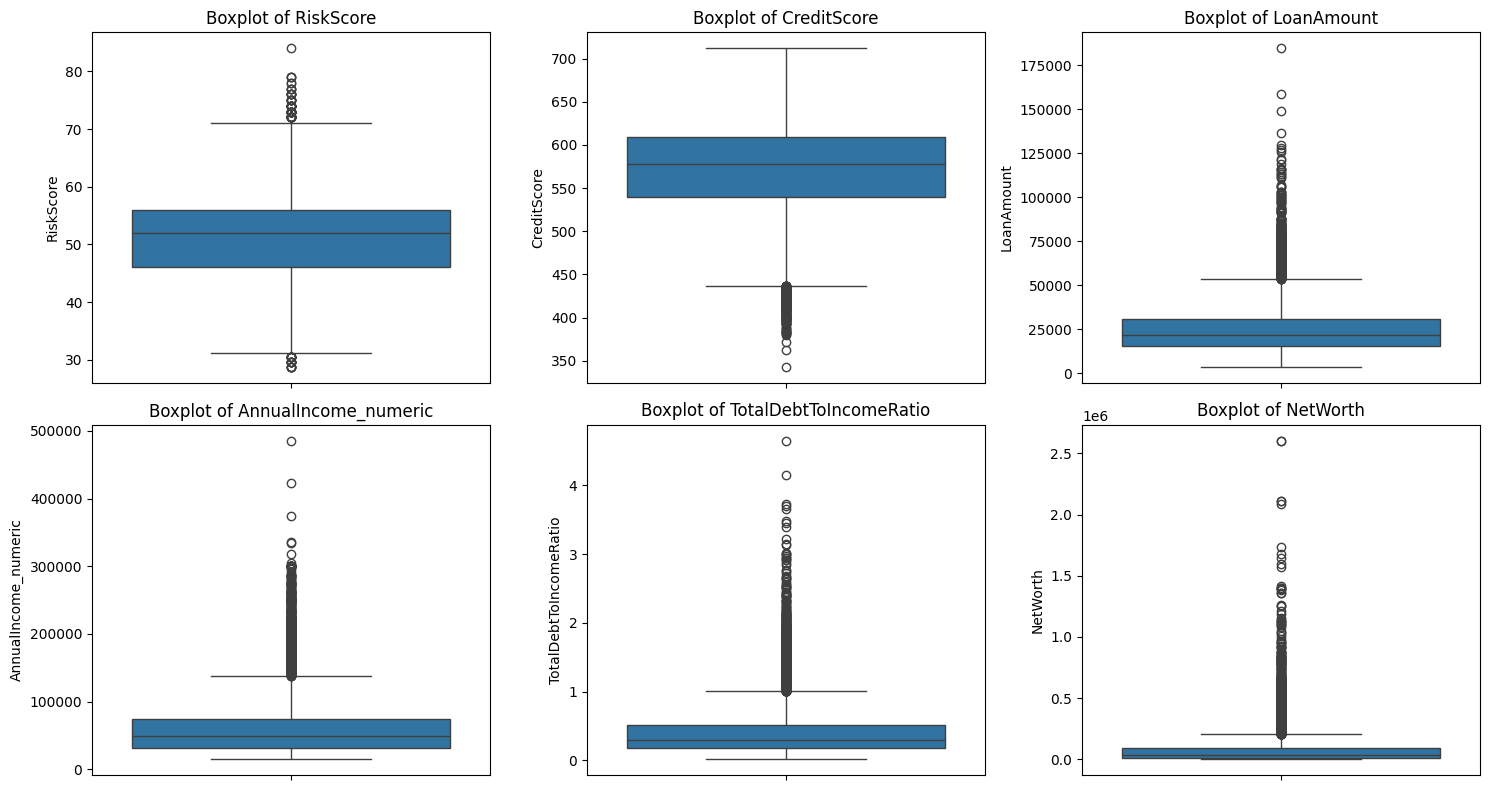

In [ ]:
df_explore = df.copy()
df_explore["AnnualIncome_numeric"] = (
    df_explore["AnnualIncome"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

plot_columns = [
    "RiskScore",
    "CreditScore",
    "LoanAmount",
    "AnnualIncome_numeric",
    "TotalDebtToIncomeRatio",
    "NetWorth"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat, plot_columns):
    sns.boxplot(data=df_explore, y=column, ax=ax)
    ax.set_title(f"Boxplot of {column}")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

In [ ]:
# Temporary numerical correlation analysis
correlation_columns = [
    "Age",
    "CreditScore",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "NumberOfOpenCreditLines",
    "NumberOfCreditInquiries",
    "DebtToIncomeRatio",
    "PreviousLoanDefaults",
    "PaymentHistory",
    "LengthOfCreditHistory",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "UtilityBillsPaymentHistory",
    "JobTenure",
    "NetWorth",
    "BaseInterestRate",
    "InterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio",
    "RiskScore"
]

correlation_matrix = df_explore[correlation_columns].corr(numeric_only=True)

risk_correlations = (
    correlation_matrix["RiskScore"]
    .drop("RiskScore")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelations with RiskScore:")
display(risk_correlations)




Correlations with RiskScore:


,RiskScore
MonthlyIncome,-0.487039
TotalDebtToIncomeRatio,0.342643
DebtToIncomeRatio,0.326500
NetWorth,-0.304333
TotalAssets,-0.297117
InterestRate,0.268203
PreviousLoanDefaults,0.258659
BaseInterestRate,0.256233
CreditScore,-0.240198
LengthOfCreditHistory,-0.177796


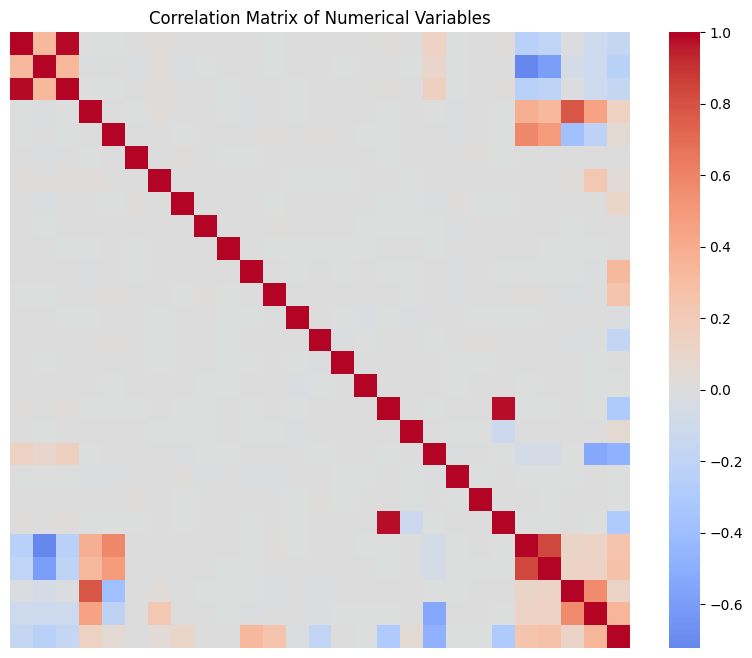

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

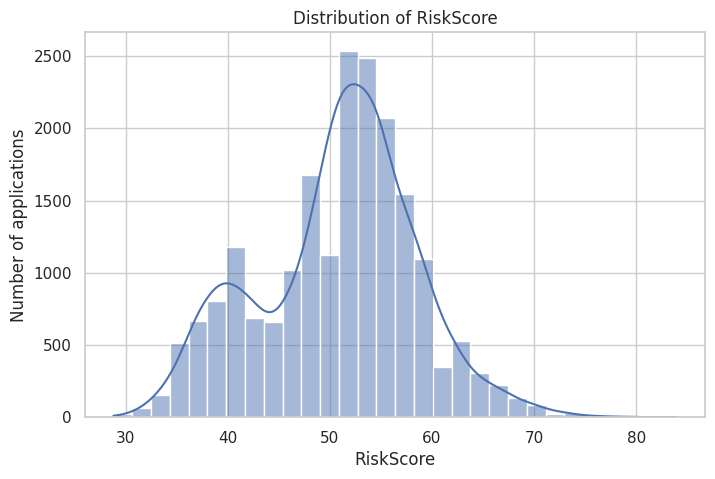

In [ ]:
sns.set_theme(style="whitegrid")

# Clean numeric version of AnnualIncome for exploration
df_explore = df.copy()

df_explore["AnnualIncome_numeric"] = (
    df_explore["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
# Distribution of the target
plt.figure(figsize=(8, 5))
sns.histplot(data=df_explore, x="RiskScore", bins=30, kde=True)
plt.title("Distribution of RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Number of applications")
plt.show()



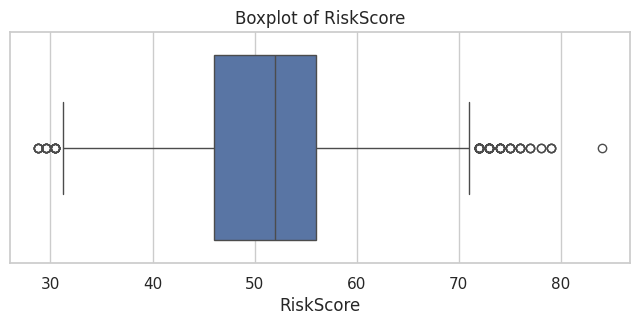

In [ ]:
# Boxplot of the target
plt.figure(figsize=(8, 3))
sns.boxplot(data=df_explore, x="RiskScore")
plt.title("Boxplot of RiskScore")
plt.show()



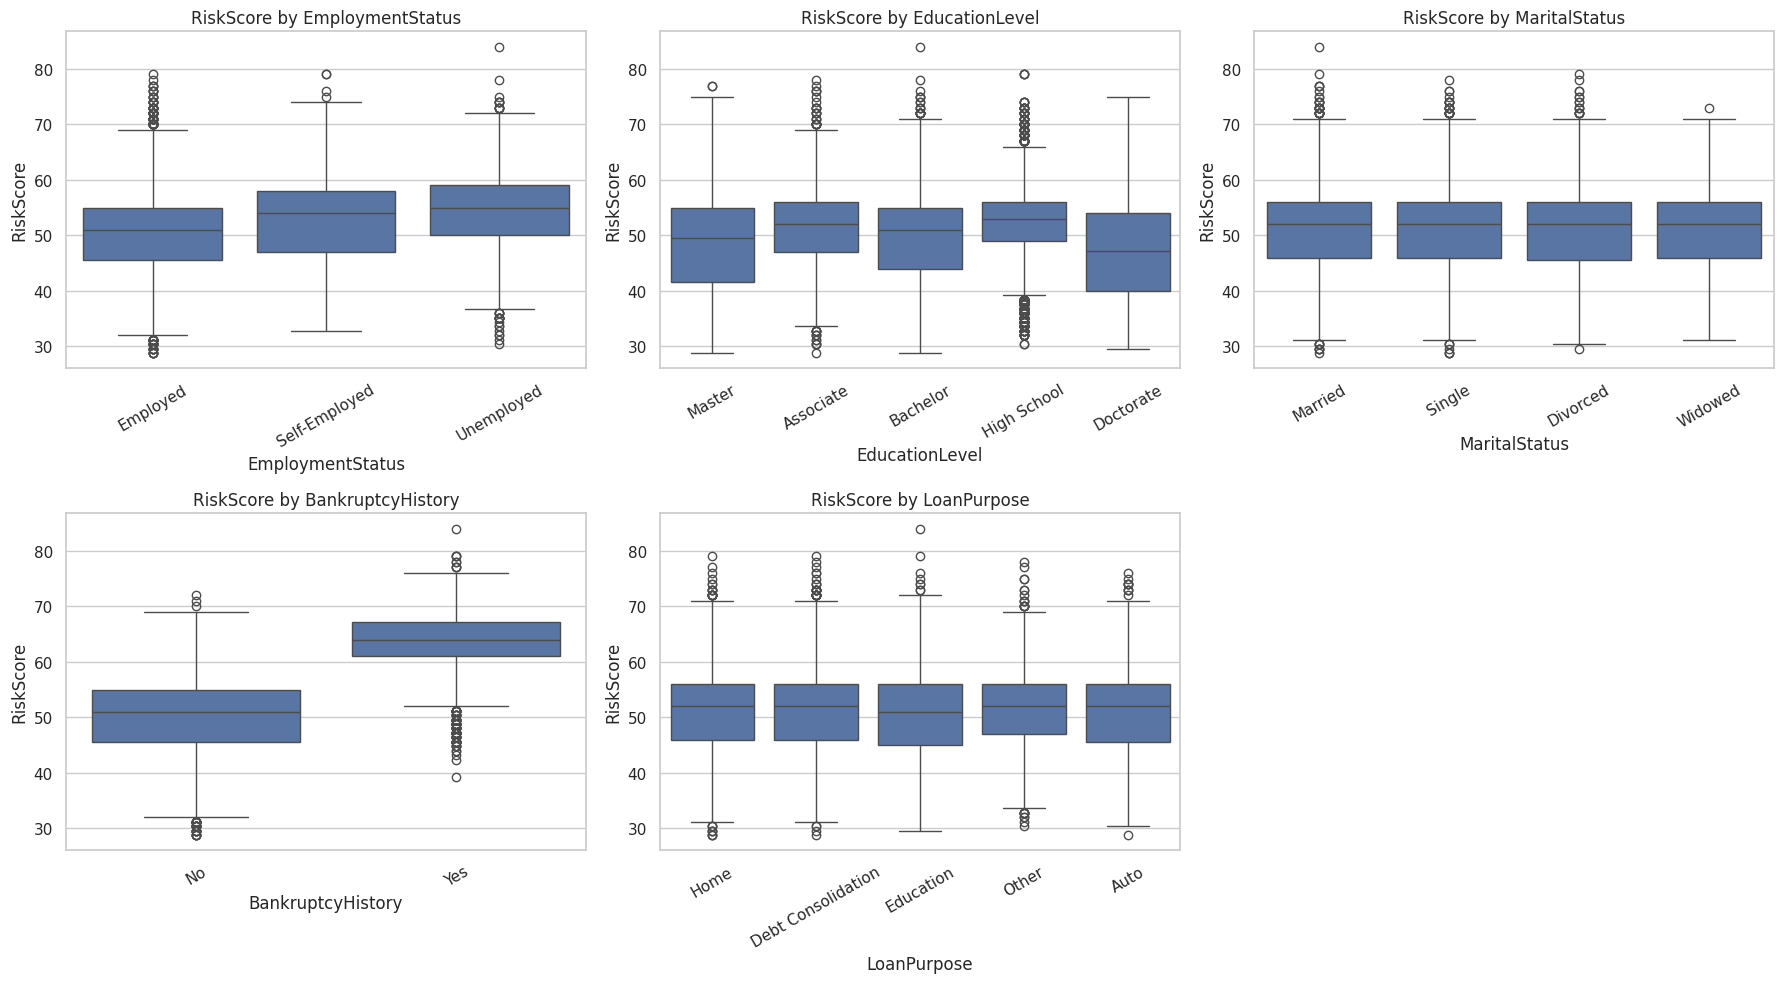

In [ ]:
# 4. RiskScore by selected categorical variables
categorical_plot_columns = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, column in zip(axes, categorical_plot_columns):
    sns.boxplot(
        data=df_explore,
        x=column,
        y="RiskScore",
        ax=ax
    )
    ax.set_title(f"RiskScore by {column}")
    ax.tick_params(axis="x", rotation=30)

#  ...
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()



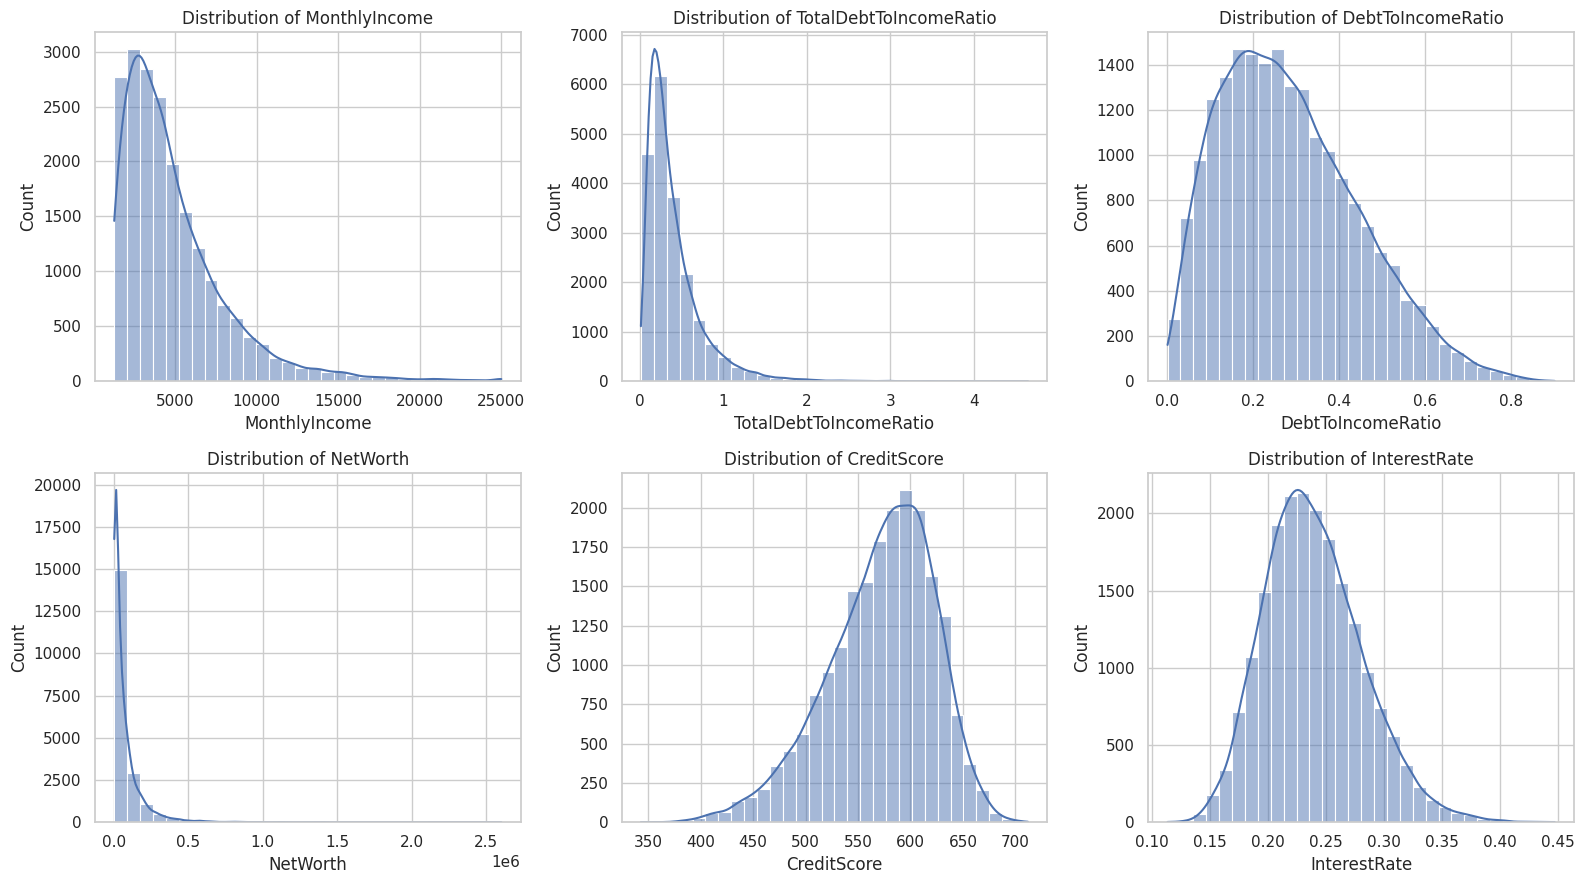

In [ ]:
# 5. Distributions of selected numerical variables
distribution_columns = [
    "MonthlyIncome",
    "TotalDebtToIncomeRatio",
    "DebtToIncomeRatio",
    "NetWorth",
    "CreditScore",
    "InterestRate"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, column in zip(axes.flat, distribution_columns):
    sns.histplot(data=df_explore, x=column, bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

The dataset had 20,000 rows and 35 columns. I used RiskScore as the target and left out LoanApproved because it’s a past approval decision that might not be known at the time of risk assessment. After converting AnnualIncome from text to numeric, there were 27 numerical features and six categorical features.

There were missing values in EducationLevel, MaritalStatus, and SavingsAccountBalance, but no fully duplicated rows. RiskScore was mostly clustered in the low to mid 50s, with some lower and higher outliers. From the numerical features, risk score seemed most related to monthly income, debt ratios, net worth, interest rate, previous defaults, and credit score.

For the categorical features, bankruptcy history stood out, applicants with a bankruptcy history had higher average risk scores. The other categorical variables had a lot of overlap between groups, so I kept them in the model instead of turning them into simple rules.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [ ]:
# Data Prep Code Here - Create New Cells As Needed
# copy
df_model = df.copy()

# Converting annual income from currency text to a numeric column
df_model["AnnualIncome"] = (
    df_model["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Defining the target
y = df_model["RiskScore"]

# Temporarily exclude riskscore and loanapproved
X = df_model.drop(columns=["RiskScore", "LoanApproved"])



In [ ]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nAnnualIncome data type:")
print(X["AnnualIncome"].dtype)

print("\nAnnualIncome summary:")
display(X["AnnualIncome"].describe())

print("\nTarget summary:")
display(y.describe())

print("\nRemaining missing values in features:")
missing_features = X.isnull().sum().sort_values(ascending=False)
display(missing_features[missing_features > 0])

print("\nTarget missing values:", y.isnull().sum())

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (20000, 33)
Target shape: (20000,)

AnnualIncome data type:
float64

AnnualIncome summary:


,AnnualIncome
count,20000.000000
mean,59161.473550
std,40350.845168
min,15000.000000
25%,31679.000000
50%,48566.000000
75%,74391.000000
max,485341.000000



Target summary:


,RiskScore
count,20000.000000
mean,50.766780
std,7.778262
min,28.800000
25%,46.000000
50%,52.000000
75%,56.000000
max,84.000000



Remaining missing values in features:


,0
MaritalStatus,1331
EducationLevel,901
SavingsAccountBalance,572



Target missing values: 0

Feature columns:
['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Defining categorical features based on their meaning
categorical_features = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]



In [ ]:
# Defining numerical features as all remaining columns
numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Numerical features:")
print(numerical_features)
print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)
print("\nNumber of categorical features:", len(categorical_features))



Numerical features:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Number of numerical features: 27

Categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

Number of categorical features: 6


In [ ]:
# Verify that every feature has been assigned exactly once
all_assigned_features = numerical_features + categorical_features

print("\nNumber of features in X:", len(X.columns))
print("Number of assigned features:", len(all_assigned_features))
print("Unique assigned features:", len(set(all_assigned_features)))

missing_assignments = set(X.columns) - set(all_assigned_features)
duplicate_assignments = [
    column for column in all_assigned_features
    if all_assigned_features.count(column) > 1
]

print("\nFeatures not assigned to a group:", missing_assignments)
print("Features assigned more than once:", set(duplicate_assignments))




Number of features in X: 33
Number of assigned features: 33
Unique assigned features: 33

Features not assigned to a group: set()
Features assigned more than once: set()


In [ ]:
# Display the data types in each group
print("\nNumerical feature data types:")
display(X[numerical_features].dtypes)

print("\nCategorical feature data types:")
display(X[categorical_features].dtypes)


Numerical feature data types:


,0
Age,int64
AnnualIncome,float64
CreditScore,int64
Experience,int64
LoanAmount,int64
LoanDuration,int64
NumberOfDependents,int64
MonthlyDebtPayments,int64
CreditCardUtilizationRate,float64
NumberOfOpenCreditLines,int64



Categorical feature data types:


,0
EmploymentStatus,object
EducationLevel,object
MaritalStatus,object
HomeOwnershipStatus,object
BankruptcyHistory,object
LoanPurpose,object


In [ ]:
from sklearn.model_selection import train_test_split

# Spliting the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nMissing values in training features:")
display(X_train.isnull().sum().sort_values(ascending=False).head())

print("\nMissing values in testing features:")
display(X_test.isnull().sum().sort_values(ascending=False).head())

print("\nTraining target summary:")
display(y_train.describe())

print("\nTesting target summary:")
display(y_test.describe())

Training feature shape: (16000, 33)
Testing feature shape: (4000, 33)
Training target shape: (16000,)
Testing target shape: (4000,)

Missing values in training features:


,0
MaritalStatus,1060
EducationLevel,717
SavingsAccountBalance,452
Age,0
CreditScore,0



Missing values in testing features:


,0
MaritalStatus,271
EducationLevel,184
SavingsAccountBalance,120
Age,0
CreditScore,0



Training target summary:


,RiskScore
count,16000.000000
mean,50.843600
std,7.750826
min,28.800000
25%,46.000000
50%,52.000000
75%,56.000000
max,84.000000



Testing target summary:


,RiskScore
count,4000.000000
mean,50.459500
std,7.880545
min,29.600000
25%,45.000000
50%,51.000000
75%,56.000000
max,79.000000


In [ ]:
# Building the preprocessing transformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])



In [ ]:
# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



In [ ]:
# Combine the numerical and categorical preprocessing flows
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing transformer created successfully.")
print(preprocessor)

Preprocessing transformer created successfully.
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'CreditScore',
                                  'Experience', 'LoanAmount', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'CreditCardUtilizationRate',
                                  'NumberOfOpenCreditLines',
                                  'NumberOfCreditInquiries',
                                  'DebtToIncomeRat...
                                  'NetWorth', 'BaseInterestRate',
                                  'InterestRate', 'MonthlyLoanPayment',
                                  'TotalDebtToIncomeRatio']),
             

AnnualIncome came in as text like "$39,948.00", so I stripped the dollar signs and commas and converted it to numeric. I then separated the target RiskScore from the features and temporarily dropped LoanApproved because it reflects a past approval decision.

For numerical features, I used median imputation since several variables were skewed with outliers. For categorical missing values, I filled them with a new category called "Missing" so that missingness wouldn't be treated as a normal category. Categorical variables were one-hot encoded.

I wrapped all of this in a ColumnTransformer and Pipeline so that imputation, encoding, and modeling were all fit on the training data only. I split the data into 80% training and 20% testing before fitting any preprocessing steps.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Baseline pipeline
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

# Ridge regression pipeline
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

print("Baseline and Ridge pipelines created successfully.")

Baseline and Ridge pipelines created successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Fit the baseline model using training data
baseline_model.fit(X_train, y_train)

# Fit the Ridge regression model using training data
ridge_model.fit(X_train, y_train)

# Generate predictions for unseen test data
baseline_predictions = baseline_model.predict(X_test)
ridge_predictions = ridge_model.predict(X_test)

# Define a function for consistent evaluation
def evaluate_regression_model(model_name, actual_values, predicted_values):
    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    r2 = r2_score(actual_values, predicted_values)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Compare the baseline and Ridge model
results = pd.DataFrame([
    evaluate_regression_model(
        "Mean baseline",
        y_test,
        baseline_predictions
    ),
    evaluate_regression_model(
        "Ridge regression",
        y_test,
        ridge_predictions
    )
])

display(results)

,Model,MAE,RMSE,R2
0,Mean baseline,6.208066,7.888916,-0.002376
1,Ridge regression,2.892203,3.752234,0.773235


In [ ]:
from sklearn.model_selection import cross_validate

# Evaluate Ridge using five-fold cross-validation on the training data
cross_validation_results = cross_validate(
    estimator=ridge_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=True
)

# Convert negative error scores into positive error values
cv_summary = pd.DataFrame({
    "Fold": range(1, 6),
    "Training_MAE": -cross_validation_results["train_mae"],
    "Validation_MAE": -cross_validation_results["test_mae"],
    "Training_RMSE": -cross_validation_results["train_rmse"],
    "Validation_RMSE": -cross_validation_results["test_rmse"],
    "Training_R2": cross_validation_results["train_r2"],
    "Validation_R2": cross_validation_results["test_r2"]
})

display(cv_summary)

print("Average validation MAE:",
      -cross_validation_results["test_mae"].mean())

print("Average validation RMSE:",
      -cross_validation_results["test_rmse"].mean())

print("Average validation R2:",
      cross_validation_results["test_r2"].mean())

print("Standard deviation of validation MAE:",
      cross_validation_results["test_mae"].std())

,Fold,Training_MAE,Validation_MAE,Training_RMSE,Validation_RMSE,Training_R2,Validation_R2
0,1,2.783899,2.801305,3.540435,3.614525,0.791042,0.783724
1,2,2.780714,2.796017,3.548908,3.583369,0.791107,0.783018
2,3,2.782725,2.802234,3.552395,3.563698,0.788753,0.793159
3,4,2.791907,2.809055,3.558777,3.540767,0.789855,0.788153
4,5,2.794774,2.784221,3.560426,3.535377,0.788955,0.791972


Average validation MAE: 2.798566396190517
Average validation RMSE: 3.567547167830618
Average validation R2: 0.7880052182445989
Standard deviation of validation MAE: 0.00828551630207845


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Numerical preprocessing for the tree-based model
numeric_tree_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing remains the same
categorical_tree_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine tree-specific preprocessing
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_tree_transformer, numerical_features),
        ("categorical", categorical_tree_transformer, categorical_features)
    ]
)

# Create a Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [ ]:
# Fit the Random Forest pipeline
random_forest_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
random_forest_predictions = random_forest_model.predict(X_test)

# Evaluate the Random Forest
random_forest_result = evaluate_regression_model(
    "Random Forest regression",
    y_test,
    random_forest_predictions
)

# Add the result to the previous comparison
model_comparison = pd.concat(
    [
        results,
        pd.DataFrame([random_forest_result])
    ],
    ignore_index=True
)

display(model_comparison)

,Model,MAE,RMSE,R2
0,Mean baseline,6.208066,7.888916,-0.002376
1,Ridge regression,2.892203,3.752234,0.773235
2,Random Forest regression,1.697763,2.725060,0.880395


In [ ]:
# Evaluate Random Forest using five-fold cross-validation
random_forest_cv = cross_validate(
    estimator=random_forest_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=True
)

random_forest_cv_summary = pd.DataFrame({
    "Fold": range(1, 6),
    "Training_MAE": -random_forest_cv["train_mae"],
    "Validation_MAE": -random_forest_cv["test_mae"],
    "Training_RMSE": -random_forest_cv["train_rmse"],
    "Validation_RMSE": -random_forest_cv["test_rmse"],
    "Training_R2": random_forest_cv["train_r2"],
    "Validation_R2": random_forest_cv["test_r2"]
})

display(random_forest_cv_summary)

print("Average validation MAE:",
      -random_forest_cv["test_mae"].mean())

print("Average validation RMSE:",
      -random_forest_cv["test_rmse"].mean())

print("Average validation R2:",
      random_forest_cv["test_r2"].mean())

,Fold,Training_MAE,Validation_MAE,Training_RMSE,Validation_RMSE,Training_R2,Validation_R2
0,1,0.633798,1.713242,1.027117,2.740217,0.982413,0.875699
1,2,0.620004,1.723740,1.006963,2.792608,0.983183,0.868217
2,3,0.627472,1.720276,1.016563,2.777717,0.982701,0.874336
3,4,0.638532,1.707953,1.032535,2.774326,0.982310,0.869940
4,5,0.632040,1.643766,1.021348,2.619400,0.982633,0.885803


Average validation MAE: 1.701795333333333
Average validation RMSE: 2.740853700414497
Average validation R2: 0.8747989737458426


In [ ]:
from sklearn.model_selection import GridSearchCV

small_parameter_grid = {
    "model__n_estimators": [100],
    "model__max_depth": [10, None],
    "model__min_samples_leaf": [1, 5]
}

small_random_forest_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=small_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=2,
    pre_dispatch=2,
    verbose=2,
    return_train_score=True
)

small_random_forest_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(small_random_forest_grid_search.best_params_)

print("\nBest cross-validation MAE:")
print(-small_random_forest_grid_search.best_score_)

# Evaluate the tuned model
small_tuned_predictions = small_random_forest_grid_search.predict(X_test)

small_tuned_result = evaluate_regression_model(
    "Tuned Random Forest regression",
    y_test,
    small_tuned_predictions
)

print("\nTuned Random Forest test results:")
display(pd.DataFrame([small_tuned_result]))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Best cross-validation MAE:
1.7532247875072242

Tuned Random Forest test results:


,Model,MAE,RMSE,R2
0,Tuned Random Forest regression,1.707198,2.740152,0.879067


The first tuning grid needed 180 model fits, which was too heavy to run, so I simplified it. I ended up testing just four combinations with 3 fold cross-validation. I still varied tree depth and minimum leaf size because the untuned random forest had a clear gap between training and validation performance, suggesting those settings mattered most.

BASELINE

A mean baseline was created as a reference point. It predicted the average training-set risk score for every test applicant. The baseline had an MAE of 6.208, RMSE of 7.889, and R² of approximately -0.002. This provided a simple benchmark for judging whether the machine-learning models learned useful patterns.

RIDGE REGRESSION

Ridge regression was selected as an interpretable linear model. It was used as a benchmark because it can work with scaled numerical variables and one-hot encoded categorical variables. Ridge achieved an MAE of 2.892, RMSE of 3.752, and R² of 0.773 on the test set. Its five-fold cross-validation results were stable, with an average validation MAE of approximately 2.799.

RANDOM FOREST

Random Forest regression was selected because it can model nonlinear relationships and interactions between features. Unlike Ridge regression, it does not require numerical scaling, although missing values still need to be imputed and categorical variables still need to be encoded.

The original Random Forest achieved an MAE of 1.698, RMSE of 2.725, and R² of 0.880 on the test set. Its average five-fold validation MAE was approximately 1.702, and its average validation R² was approximately 0.875. These results were better than both the baseline and Ridge regression.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

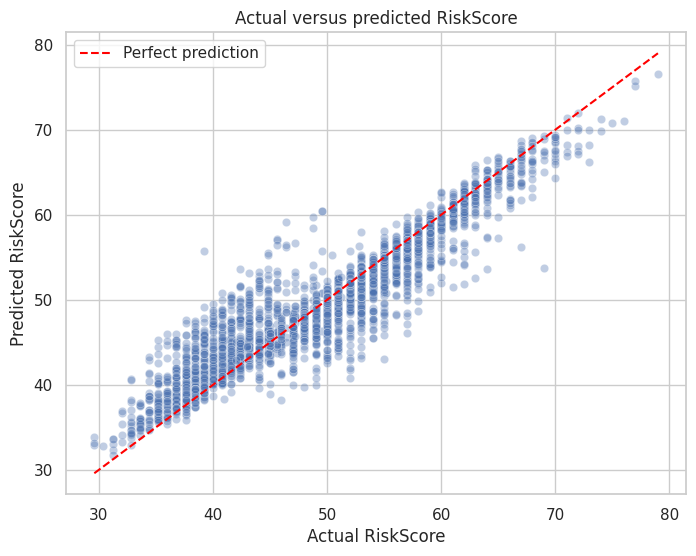

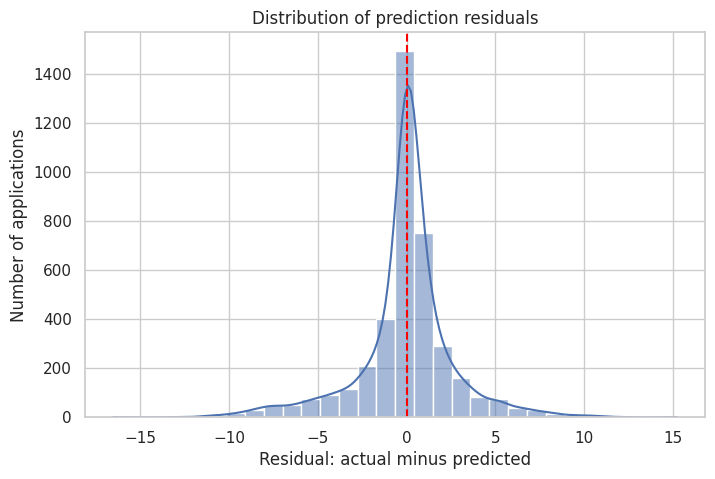

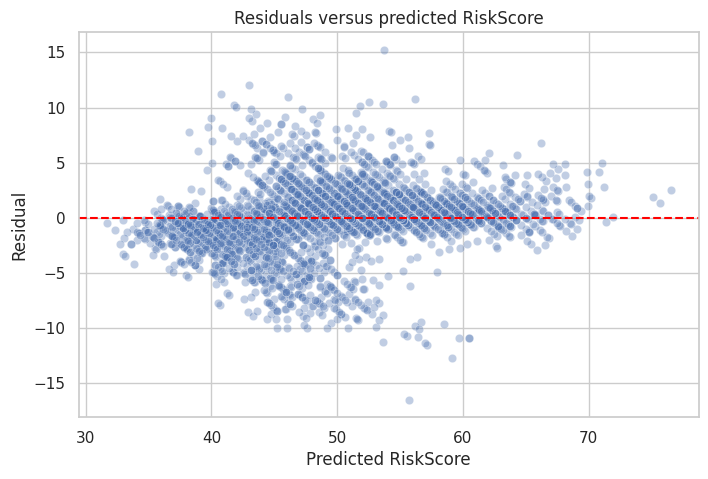

Largest absolute errors:


,ActualRiskScore,PredictedRiskScore,Residual,AbsoluteError
361,39.2,55.716000,-16.516000,16.516000
15565,69.0,53.760000,15.240000,15.240000
4505,46.4,59.148000,-12.748000,12.748000
4045,55.0,42.982667,12.017333,12.017333
8426,45.6,57.170667,-11.570667,11.570667
6490,45.6,56.977333,-11.377333,11.377333
2279,42.4,53.673333,-11.273333,11.273333
11402,52.0,40.780000,11.220000,11.220000
7704,57.0,46.057333,10.942667,10.942667
7089,48.8,59.708000,-10.908000,10.908000


Final model metrics:


,Model,MAE,RMSE,R2
0,Final Random Forest regression,1.697763,2.72506,0.880395


In [ ]:
final_predictions = random_forest_predictions

# Calculate residuals
residuals = y_test - final_predictions

# Create a dataframe for error analysis
error_analysis = X_test.copy()
error_analysis["ActualRiskScore"] = y_test
error_analysis["PredictedRiskScore"] = final_predictions
error_analysis["Residual"] = residuals
error_analysis["AbsoluteError"] = np.abs(residuals)

# Predicted versus actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test,
    y=final_predictions,
    alpha=0.35
)

# Ideal prediction line
line_min = min(y_test.min(), final_predictions.min())
line_max = max(y_test.max(), final_predictions.max())

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual versus predicted RiskScore")
plt.xlabel("Actual RiskScore")
plt.ylabel("Predicted RiskScore")
plt.legend()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of prediction residuals")
plt.xlabel("Residual: actual minus predicted")
plt.ylabel("Number of applications")
plt.show()

# Residuals versus predictions
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=final_predictions,
    y=residuals,
    alpha=0.35
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals versus predicted RiskScore")
plt.xlabel("Predicted RiskScore")
plt.ylabel("Residual")
plt.show()

# Largest absolute errors
print("Largest absolute errors:")
display(
    error_analysis[
        [
            "ActualRiskScore",
            "PredictedRiskScore",
            "Residual",
            "AbsoluteError"
        ]
    ]
    .sort_values("AbsoluteError", ascending=False)
    .head(10)
)

print("Final model metrics:")
display(pd.DataFrame([
    evaluate_regression_model(
        "Final Random Forest regression",
        y_test,
        final_predictions
    )
]))

Number of transformed features: 52
Number of importance values: 52

Top 20 transformed features:


,Feature,Importance
26,numeric__TotalDebtToIncomeRatio,0.162386
11,numeric__DebtToIncomeRatio,0.120675
22,numeric__NetWorth,0.108299
19,numeric__MonthlyIncome,0.084581
46,categorical__BankruptcyHistory_Yes,0.080802
24,numeric__InterestRate,0.065652
45,categorical__BankruptcyHistory_No,0.063818
12,numeric__PreviousLoanDefaults,0.062834
1,numeric__AnnualIncome,0.057491
2,numeric__CreditScore,0.043748


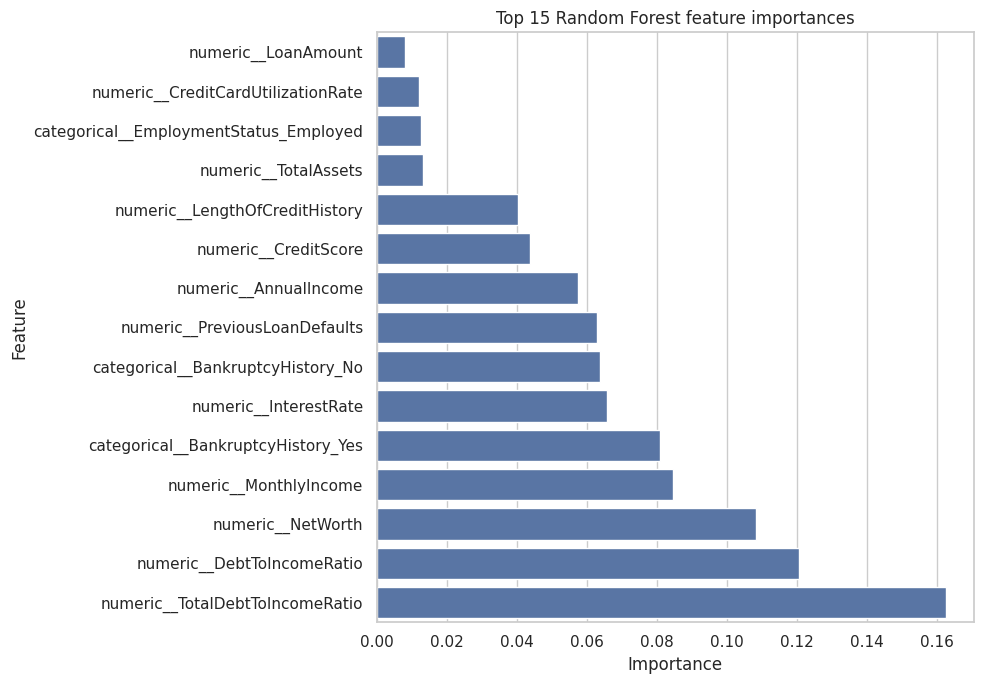

In [ ]:
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

fitted_random_forest = random_forest_model.named_steps["model"]

transformed_feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance_values = fitted_random_forest.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": feature_importance_values
}).sort_values(
    "Importance",
    ascending=False
)

print("Number of transformed features:", len(transformed_feature_names))
print("Number of importance values:", len(feature_importance_values))

print("\nTop 20 transformed features:")
display(feature_importance.head(20))

# Plot the top 15 features
top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Add predictions and errors to a copy of the test data
segment_analysis = X_test.copy()

segment_analysis["ActualRiskScore"] = y_test
segment_analysis["PredictedRiskScore"] = final_predictions
segment_analysis["AbsoluteError"] = np.abs(
    segment_analysis["ActualRiskScore"]
    - segment_analysis["PredictedRiskScore"]
)

def calculate_segment_metrics(data, segment_column):
    return (
        data.groupby(segment_column)
        .agg(
            Applications=("AbsoluteError", "size"),
            MeanAbsoluteError=("AbsoluteError", "mean"),
            MeanActualRisk=("ActualRiskScore", "mean"),
            MeanPredictedRisk=("PredictedRiskScore", "mean")
        )
        .sort_values("MeanAbsoluteError", ascending=False)
    )

segment_columns = [
    "EmploymentStatus",
    "BankruptcyHistory",
    "LoanPurpose",
    "EducationLevel"
]

for column in segment_columns:
    print(f"\nSegment performance by {column}:")
    display(calculate_segment_metrics(segment_analysis, column))


Segment performance by EmploymentStatus:


,Applications,MeanAbsoluteError,MeanActualRisk,MeanPredictedRisk
EmploymentStatus,,,,
Unemployed,269,2.184188,53.793309,52.455554
Self-Employed,307,2.147548,52.033876,51.440265
Employed,3424,1.619219,50.056425,50.270225



Segment performance by BankruptcyHistory:


,Applications,MeanAbsoluteError,MeanActualRisk,MeanPredictedRisk
BankruptcyHistory,,,,
Yes,200,2.247067,63.529000,63.148773
No,3800,1.668852,49.771632,49.841632



Segment performance by LoanPurpose:


,Applications,MeanAbsoluteError,MeanActualRisk,MeanPredictedRisk
LoanPurpose,,,,
Other,397,1.773065,50.718388,50.853031
Auto,793,1.770932,50.027491,50.161638
Education,614,1.750864,50.643322,50.623273
Home,1203,1.691254,50.509726,50.446001
Debt Consolidation,993,1.584275,50.526485,50.646422



Segment performance by EducationLevel:


,Applications,MeanAbsoluteError,MeanActualRisk,MeanPredictedRisk
EducationLevel,,,,
Doctorate,186,2.563118,46.552688,48.045842
Master,621,1.945067,48.826731,49.306841
Bachelor,1167,1.747334,49.877806,50.032839
Associate,769,1.612905,50.520156,50.523209
High School,1073,1.514407,52.053495,51.666665


In [ ]:
top_features = feature_importance.head(20)

display(top_features)

related_features = {
    "Income and wealth": [
        "AnnualIncome",
        "MonthlyIncome",
        "NetWorth",
        "TotalAssets",
        "TotalLiabilities"
    ],
    "Debt burden": [
        "DebtToIncomeRatio",
        "TotalDebtToIncomeRatio",
        "MonthlyDebtPayments",
        "MonthlyLoanPayment"
    ],
    "Credit history": [
        "CreditScore",
        "PreviousLoanDefaults",
        "LengthOfCreditHistory",
        "PaymentHistory"
    ],
    "Pricing": [
        "BaseInterestRate",
        "InterestRate"
    ]
}

for group_name, columns in related_features.items():
    available_columns = [
        column for column in columns
        if column in X.columns
    ]

    print(f"\n{group_name}:")
    print(available_columns)

,Feature,Importance
26,numeric__TotalDebtToIncomeRatio,0.162386
11,numeric__DebtToIncomeRatio,0.120675
22,numeric__NetWorth,0.108299
19,numeric__MonthlyIncome,0.084581
46,categorical__BankruptcyHistory_Yes,0.080802
24,numeric__InterestRate,0.065652
45,categorical__BankruptcyHistory_No,0.063818
12,numeric__PreviousLoanDefaults,0.062834
1,numeric__AnnualIncome,0.057491
2,numeric__CreditScore,0.043748



Income and wealth:
['AnnualIncome', 'MonthlyIncome', 'NetWorth', 'TotalAssets', 'TotalLiabilities']

Debt burden:
['DebtToIncomeRatio', 'TotalDebtToIncomeRatio', 'MonthlyDebtPayments', 'MonthlyLoanPayment']

Credit history:
['CreditScore', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'PaymentHistory']

Pricing:
['BaseInterestRate', 'InterestRate']


## Evaluation and conclusion

The Random Forest model performed best, with an MAE of 1.70, RMSE of 2.73, and R² of 0.88. This means its predictions were generally close to the actual Risk score values. The model performed well overall, although it made larger errors for some applicants and was less accurate for groups such as unemployed applicants, applicants with bankruptcy history, and the Doctorate group. The most important features included debt to income ratios, net worth, monthly income, bankruptcy history, interest rate, previous defaults, and credit score. Overall, the model could help loan officers assess risk, but it should not make final decisions without human review and further checks for bias and data leakage.